In [3]:
from pathlib import Path
import io
import random
import sqlite3
import tarfile
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

import sys
sys.path.insert(0, "/home/austen/DeepStreetSearch")

from config import NUM_VIEWS
from modules.panorama import get_panorama_subimage


DATASET_ROOT = Path(
    "/home/austen/Street-View-Harvester/datasets/world"
)

METADATA_PATH = DATASET_ROOT / "metadata_full.csv"
IMAGES_DIR = DATASET_ROOT / "images"
DESCRIPTIONS_DIR = DATASET_ROOT / "descriptions"

PROMPT_INDICES = (0, 1, 2, 3)

metadata = pd.read_csv(METADATA_PATH)

print(f"Panoramas:       {len(metadata):,}")
print(f"Unique panoids:  {metadata['panoid'].nunique():,}")
print(f"Views/panorama:  {NUM_VIEWS}")
print(f"Prompts/view:    {len(PROMPT_INDICES)}")
print(f"Expected rows:   {len(metadata) * NUM_VIEWS * len(PROMPT_INDICES):,}")

Panoramas:       1,033,108
Unique panoids:  1,033,108
Views/panorama:  6
Prompts/view:    4
Expected rows:   24,794,592


In [ ]:
database_paths = sorted(DESCRIPTIONS_DIR.glob("shard_*.sqlite"))

total_rows = 0

for database_path in database_paths:
    connection = sqlite3.connect(
        f"file:{database_path.resolve()}?mode=ro",
        uri=True,
    )

    total_rows += connection.execute(
        "SELECT COUNT(*) FROM descriptions"
    ).fetchone()[0]

    connection.close()


expected_rows = len(metadata) * NUM_VIEWS * len(PROMPT_INDICES)

print(f"Shard databases:       {len(database_paths):,}")
print(f"Expected descriptions: {expected_rows:,}")
print(f"Actual descriptions:   {total_rows:,}")
print(f"Difference:            {total_rows - expected_rows:+,}")

if total_rows == expected_rows:
    print("\nPASS: Total description count is correct.")
else:
    print("\nFAIL: Description count does not match.")

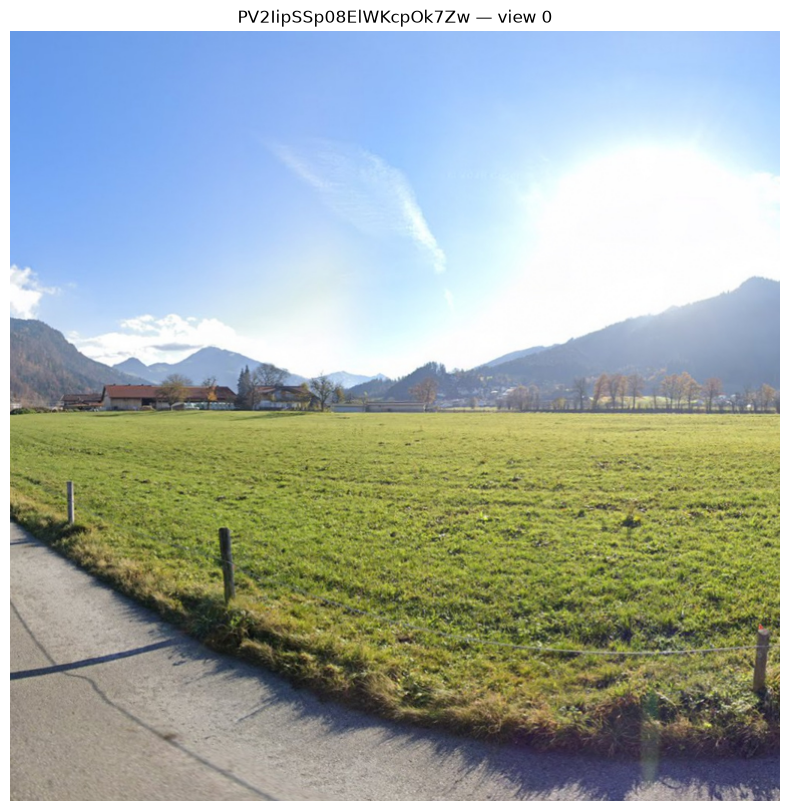

Panoid:   PV2IipSSp08ElWKcpOk7Zw
Shard:    shard_000971.zip
View:     0

PROMPT 1
--------------------------------------------------------------------------------
Sunlit meadow stretches beside a winding asphalt road, bordered by wire fences and sparse wooden posts. Distant alpine slopes rise behind scattered farmhouses with red roofs. Bare trees dot the horizon, while a bright sun casts lens flares across the vivid green field.

PROMPT 2
--------------------------------------------------------------------------------
A sun-drenched Alpine meadow borders a quiet asphalt road, flanked by simple wooden posts and wire fencing. Distant farmhouses with red-tiled roofs nestle beneath rolling, forested hills under a vast, cloud-sparse blue sky.



In [ ]:
def resolve_archive_path(image_path: str) -> tuple[Path, str]:
    archive_name, member_name = image_path.split("::", 1)
    archive_path = Path(archive_name)

    if not archive_path.is_absolute():
        candidates = [
            DATASET_ROOT / archive_path,
            IMAGES_DIR / archive_path.name,
        ]

        for candidate in candidates:
            if candidate.exists():
                archive_path = candidate
                break
        else:
            raise FileNotFoundError(
                f"Could not locate archive for {image_path}"
            )

    return archive_path, member_name


def load_panorama(image_path: str) -> tuple[Image.Image, Path]:
    archive_path, member_name = resolve_archive_path(image_path)

    if archive_path.suffix == ".tar":
        with tarfile.open(archive_path, "r:*") as archive:
            member = archive.getmember(member_name)
            fileobj = archive.extractfile(member)

            if fileobj is None:
                raise FileNotFoundError(member_name)

            with fileobj:
                image = Image.open(fileobj)
                image.load()
                panorama = image.convert("RGB")

    elif archive_path.suffix == ".zip":
        with zipfile.ZipFile(archive_path, "r") as archive:
            with archive.open(member_name) as fileobj:
                image = Image.open(fileobj)
                image.load()
                panorama = image.convert("RGB")

    else:
        raise ValueError(
            f"Unsupported archive type: {archive_path}"
        )

    return panorama, archive_path


row = metadata.sample(1).iloc[0]

panoid = str(row["panoid"])
view_index = random.randrange(NUM_VIEWS)

panorama, archive_path = load_panorama(row["image_path"])
crop = get_panorama_subimage(panorama, view_index)

database_path = (
    DESCRIPTIONS_DIR
    / f"{archive_path.name}.sqlite"
)

connection = sqlite3.connect(
    f"file:{database_path.resolve()}?mode=ro",
    uri=True,
)

descriptions = dict(
    connection.execute(
        """
        SELECT prompt_index, description
        FROM descriptions
        WHERE panoid = ?
          AND subimage_index = ?
        ORDER BY prompt_index
        """,
        (panoid, view_index),
    ).fetchall()
)

connection.close()


plt.figure(figsize=(10, 10))
plt.imshow(crop)
plt.axis("off")
plt.title(
    f"{panoid} — view {view_index}"
)
plt.show()

print(f"Panoid:   {panoid}")
print(f"Shard:    {archive_path.name}")
print(f"View:     {view_index}")
print()

for prompt_index in PROMPT_INDICES:
    print(f"PROMPT {prompt_index + 1}")
    print("-" * 80)
    print(descriptions.get(prompt_index, "<MISSING>"))
    print()

In [ ]:
SAMPLE_SIZE = min(10_000, len(metadata))

sample = metadata.sample(
    SAMPLE_SIZE,
    random_state=42,
).copy()


def shard_name_from_image_path(image_path: str) -> str:
    archive_name = image_path.split("::", 1)[0]
    return Path(archive_name).name


sample["shard"] = sample["image_path"].map(
    shard_name_from_image_path
)

expected_keys = {
    (
        str(row.panoid),
        view_index,
        prompt_index,
    )
    for row in sample.itertuples()
    for view_index in range(NUM_VIEWS)
    for prompt_index in PROMPT_INDICES
}

actual = {}
missing_databases = []

for shard_name, group in sample.groupby("shard"):
    database_path = (
        DESCRIPTIONS_DIR
        / f"{shard_name}.sqlite"
    )

    if not database_path.exists():
        missing_databases.append(str(database_path))
        continue

    panoids = group["panoid"].astype(str).tolist()

    connection = sqlite3.connect(
        f"file:{database_path.resolve()}?mode=ro",
        uri=True,
    )

    # Keep batches below SQLite parameter limits.
    for start in range(0, len(panoids), 500):
        batch = panoids[start:start + 500]

        placeholders = ",".join(
            "?" for _ in batch
        )

        rows = connection.execute(
            f"""
            SELECT
                panoid,
                subimage_index,
                prompt_index,
                description
            FROM descriptions
            WHERE panoid IN ({placeholders})
            """,
            batch,
        ).fetchall()

        for panoid, view_index, prompt_index, description in rows:
            key = (
                str(panoid),
                view_index,
                prompt_index,
            )
            actual[key] = description

    connection.close()


actual_keys = set(actual)

missing_keys = expected_keys - actual_keys
unexpected_keys = actual_keys - expected_keys

empty_keys = {
    key
    for key, description in actual.items()
    if key in expected_keys
    and not description.strip()
}


print(f"Panoramas checked:       {SAMPLE_SIZE:,}")
print(f"Expected descriptions:   {len(expected_keys):,}")
print(f"Found descriptions:      {len(actual_keys & expected_keys):,}")
print()
print(f"Missing descriptions:    {len(missing_keys):,}")
print(f"Empty descriptions:      {len(empty_keys):,}")
print(f"Unexpected descriptions: {len(unexpected_keys):,}")
print(f"Missing shard DBs:       {len(missing_databases):,}")

if (
    not missing_keys
    and not empty_keys
    and not missing_databases
):
    print("\nPASS: sampled panoramas are structurally complete.")
else:
    print("\nFAIL: sampled panoramas contain problems.")

Panoramas checked:       10,000
Expected descriptions:   120,000
Found descriptions:      120,000

Missing descriptions:    0
Empty descriptions:      0
Unexpected descriptions: 0
Missing shard DBs:       0

PASS: sampled panoramas are structurally complete.


In [ ]:
problems = []

for panoid, view_index, prompt_index in sorted(missing_keys):
    problems.append({
        "panoid": panoid,
        "view": view_index,
        "prompt": prompt_index + 1,
        "problem": "missing",
    })

for panoid, view_index, prompt_index in sorted(empty_keys):
    problems.append({
        "panoid": panoid,
        "view": view_index,
        "prompt": prompt_index + 1,
        "problem": "empty description",
    })

problems_df = pd.DataFrame(problems)

if problems_df.empty:
    print("No problems found.")
else:
    display(problems_df.head(100))

    print(
        f"\nShowing first {min(100, len(problems_df)):,} "
        f"of {len(problems_df):,} problems."
    )